# 05 · Multi-line portfolio

Six CAS lines, one loss-ratio distribution fitted per line (lognormal vs Burr XII), then combined into an illustrative portfolio. The CAS data are in USD thousands; results below are shown in USD millions. This is company-level data, not the policy claims from 01–04 (those are EUR).

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from portfolio_model import (
    LINES, MIN_PREMIUM, load_and_clean_line, fit_line_marginal, simulate_line,
    uniform_from_line, MultiLineResults, LossRatioMarginal, marginal_from_fit,
    empirical_marginal, empirical_gpd_marginal, independent_portfolio, marginal_alternatives,
)
from risk_measures import var, es, portfolio_summary

RNG_SEED = 42
USDM = lambda v: f'USD {v/1000:,.1f}m'   # data are in USD thousands; results are displayed in USD millions

## What one row is

One company, one line, one accident year, read at development lag 10. Loss ratio = incurred loss / net earned premium. Lag 10 isn't necessarily final, so this is only a proxy for ultimate. The spread across companies is not one insurer's annual loss distribution.

## Data checks

Keep companies with a complete accident-year × lag grid and drop rows with net earned premium under USD 1 million. Non-positive loss ratios stay in the audit table but are left out of the fits.

In [2]:
reports = {}
cleaned = {}
for line in LINES:
    cred, rpt = load_and_clean_line(line, data_dir=DATA_DIR, min_premium=MIN_PREMIUM)
    reports[line] = rpt
    cleaned[line] = cred

report_df = pd.DataFrame([r.__dict__ for r in reports.values()])
report_df

,line,n_companies_raw,n_companies_full_square,n_ultimate_rows,n_nonpositive_premium,n_after_credibility_filter,n_lr_nonpositive,lr_nonpositive_min
0,ppauto,143,121,1210,112,953,1,-1.136
1,comauto,157,137,1370,188,736,1,-0.611
2,wkcomp,132,110,1100,272,597,13,-0.029
3,othliab,236,206,2060,233,786,2,-0.009
4,medmal,34,32,320,118,143,0,0.043
5,prodliab,70,59,590,132,131,1,0.000


wkcomp has 13 non-positive ratios out of 597 rows; the other lines have 0–2. The extract doesn't say why. Dropping them changes the population a little, and the effect on risk is unknown.

## Marginal fits

Lognormal vs Burr XII, compared on AIC and quantile errors. Burr has three free parameters (location fixed at 0).

In [3]:
fits = {}
diag_rows = []
for line in LINES:
    fit = fit_line_marginal(cleaned[line])
    fit.line = line
    fits[line] = fit

    lr = cleaned[line].loc[cleaned[line]['LossRatio'] > 0, 'LossRatio'].to_numpy()
    qs = [0.90, 0.95, 0.99]
    emp_q = np.quantile(lr, qs)
    ln_q = stats.lognorm.ppf(qs, fit.ln_sigma, scale=np.exp(fit.ln_mu))
    burr_q = stats.burr12.ppf(qs, fit.burr_c, fit.burr_k, loc=0, scale=fit.burr_scale)
    diag_rows.append(dict(
        line=line, n=fit.n_fit, AIC_lognormal=fit.ln_aic, AIC_burr=fit.burr_aic, chosen=fit.chosen,
        err90_LN=100*(ln_q[0]/emp_q[0]-1), err95_LN=100*(ln_q[1]/emp_q[1]-1), err99_LN=100*(ln_q[2]/emp_q[2]-1),
        err90_Burr=100*(burr_q[0]/emp_q[0]-1), err95_Burr=100*(burr_q[1]/emp_q[1]-1), err99_Burr=100*(burr_q[2]/emp_q[2]-1),
    ))

diag_table = pd.DataFrame(diag_rows)
diag_table.round(1)

moments = pd.DataFrame([dict(line=l, family=f.chosen, burr_tail_index=f.burr_c*f.burr_k, finite_mean=f.chosen!='burr12' or f.burr_c*f.burr_k>1, finite_variance=f.chosen!='burr12' or f.burr_c*f.burr_k>2) for l,f in fits.items()])
display(diag_table.round(2)); display(moments)
assert moments.finite_mean.all(), 'Selected marginal has no finite mean'

,line,n,AIC_lognormal,AIC_burr,chosen,err90_LN,err95_LN,err99_LN,err90_Burr,err95_Burr,err99_Burr
0,ppauto,952,-399.080,-637.300,burr12,10.320,9.220,4.240,2.600,-0.970,-8.670
1,comauto,735,-161.590,-209.380,burr12,5.890,5.720,6.820,0.990,-0.960,-1.320
2,wkcomp,584,818.780,420.800,burr12,59.590,56.940,-38.630,14.660,8.530,-56.550
3,othliab,784,438.710,324.890,burr12,13.860,16.470,12.040,1.420,-0.130,-7.250
4,medmal,143,219.240,211.320,burr12,10.430,10.900,39.090,0.660,-5.260,5.670
5,prodliab,130,112.050,94.580,burr12,25.560,28.790,49.740,7.360,0.100,-2.690


,line,family,burr_tail_index,finite_mean,finite_variance
0,ppauto,burr12,10.739,True,True
1,comauto,burr12,7.307,True,True
2,wkcomp,burr12,2.939,True,True
3,othliab,burr12,4.304,True,True
4,medmal,burr12,5.841,True,True
5,prodliab,burr12,5.573,True,True


Burr has the lower AIC in all six lines, by the widest margin for wkcomp (420.8 vs 818.8). The tail index is above 2 everywhere, so mean and variance exist (lowest is wkcomp at 2.94). Burr is not better at every quantile: at 99% the lognormal error is smaller for ppauto and wkcomp.

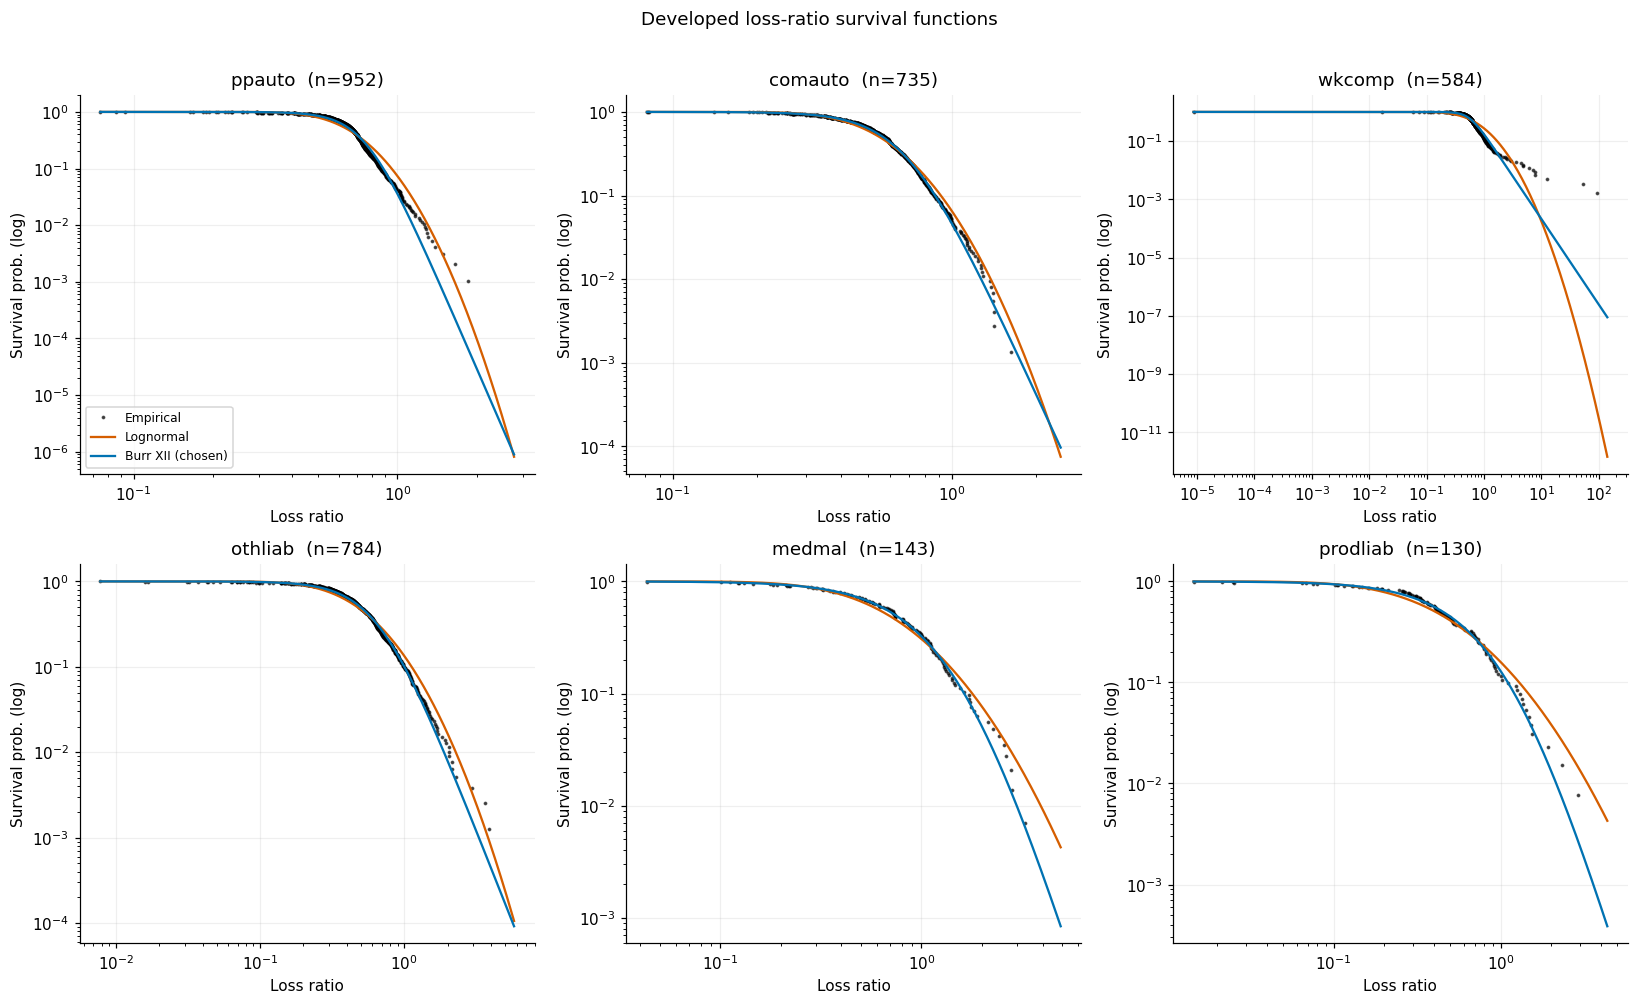

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, line in zip(axes.flat, LINES):
    lr = cleaned[line].loc[cleaned[line]['LossRatio'] > 0, 'LossRatio'].to_numpy()
    fit = fits[line]
    lr_sorted = np.sort(lr)
    surv_emp = 1 - np.arange(1, len(lr_sorted)+1)/(len(lr_sorted)+1)
    x_grid = np.geomspace(lr_sorted.min(), lr_sorted.max()*1.5, 500)
    surv_ln = 1 - stats.lognorm.cdf(x_grid, fit.ln_sigma, scale=np.exp(fit.ln_mu))
    surv_burr = 1 - stats.burr12.cdf(x_grid, fit.burr_c, fit.burr_k, loc=0, scale=fit.burr_scale)

    ax.plot(lr_sorted, surv_emp, '.', ms=3, color='k', label='Empirical', alpha=0.6)
    ax.plot(x_grid, surv_ln, '-', color='C3', label='Lognormal')
    ax.plot(x_grid, surv_burr, '-', color='C0', label='Burr XII (chosen)')
    ax.set_yscale('log'); ax.set_xscale('log')
    ax.set_title(f'{line}  (n={fit.n_fit})')
    ax.set_xlabel('Loss ratio'); ax.set_ylabel('Survival prob. (log)')
axes.flat[0].legend(fontsize=8)
plt.suptitle('Developed loss-ratio survival functions', y=1.01)
plt.tight_layout(); plt.show()

## Illustrative portfolio

Each line is scaled by its median company premium (table below, USD millions). The six medians don't describe a real insurer.

In [5]:
book_table = pd.DataFrame({'Line': LINES, 'Book premium (USD m)': [fits[l].book_premium / 1000 for l in LINES]})
book_table

,Line,Book premium (USD m)
0,ppauto,11.786
1,comauto,5.618
2,wkcomp,11.395
3,othliab,4.063
4,medmal,4.828
5,prodliab,3.668


In [6]:
N_SIM = 500_000

base = independent_portfolio(fits, N_SIM, seed_base=1000)
summ = portfolio_summary(base.per_line, base.total)
standalone_mean, standalone_v995, standalone_es = summ['standalone_mean'], summ['standalone_var'], summ['standalone_es']
sum_sa, port_mean, port_v995, port_es = summ['sum_standalone_var'], summ['portfolio_mean'], summ['portfolio_var'], summ['portfolio_es']
d_var, d_k = summ['d_var'], summ['d_k']
port_losses = base.total

line_table = pd.DataFrame({
    'mean (USD m)': {l: standalone_mean[l] / 1000 for l in LINES},
    'VaR 99.5% (USD m)': {l: standalone_v995[l] / 1000 for l in LINES},
    'K = VaR - mean (USD m)': {l: (standalone_v995[l] - standalone_mean[l]) / 1000 for l in LINES},
})
display(line_table.round(1))
print(f"Sum of stand-alone VaR 99.5%:         {USDM(sum_sa)}")
print(f"Portfolio VaR 99.5% (independence):   {USDM(port_v995)}    mean {USDM(port_mean)}    ES 99.5% {USDM(port_es)}")
print(f"Sum of stand-alone K:                 {USDM(summ['sum_standalone_k'])}")
print(f"Portfolio K = VaR - mean:             {USDM(summ['portfolio_k'])}")
print()
print(f"VaR diversification  D_VaR = 1 - VaR(portfolio) / sum VaR_i          = {d_var:.1%}")
print(f"Capital-proxy diversification  D_K = 1 - K(portfolio) / sum K_i       = {d_k:.1%}")


,mean (USD m),VaR 99.5% (USD m),K = VaR - mean (USD m)
ppauto,7.900,14.400,6.500
comauto,3.300,7.900,4.600
wkcomp,8.400,38.900,30.400
othliab,2.300,9.000,6.700
medmal,4.200,16.600,12.400
prodliab,2.100,9.300,7.200


Sum of stand-alone VaR 99.5%:         USD 96.1m
Portfolio VaR 99.5% (independence):   USD 60.3m    mean USD 28.3m    ES 99.5% USD 79.7m
Sum of stand-alone K:                 USD 67.9m
Portfolio K = VaR - mean:             USD 32.0m

VaR diversification  D_VaR = 1 - VaR(portfolio) / sum VaR_i          = 37.3%
Capital-proxy diversification  D_K = 1 - K(portfolio) / sum K_i       = 52.8%


In [7]:
import copy
avg_premium = float(np.mean([fits[l].book_premium for l in LINES]))
fits_equal = copy.deepcopy(fits)
for f in fits_equal.values():
    f.book_premium = avg_premium

eq = independent_portfolio(fits_equal, N_SIM, seed_base=2000)
summ_eq = portfolio_summary(eq.per_line, eq.total)

weighting_check = pd.DataFrame({
    'Portfolio construction': ['Representative (each line at its own median premium)', f'Equal premium (USD {avg_premium/1000:,.1f}m each)'],
    'D_VaR': [d_var, summ_eq['d_var']],
    'D_K': [d_k, summ_eq['d_k']],
})
weighting_check.round(3)


,Portfolio construction,D_VaR,D_K
0,Representative (each line at its own median pr...,0.373,0.528
1,Equal premium (USD 6.9m each),0.442,0.614


D_VaR and D_K are two different measures and are reported separately. With independence, the sum of stand-alone VaR is USD 96.1m against a portfolio VaR of USD 60.3m, so D_VaR = 37.3%. On the capital-proxy basis K = VaR − E[loss] (mean losses are netted off both sides) the benefit is larger, D_K = 52.8%, because the expected losses do not diversify. With equal premiums (USD 6.9m each) D_VaR is 44.2%, so the weights matter as much as the dependence assumption.

## Workers' compensation: marginal-model risk

Notebook 06 will attribute most of the tail capital to workers' compensation, so the choice of its marginal matters. The table in the fitting section shows that the selected Burr XII understates the empirical 99% quantile of wkcomp by more than half. AIC over the whole sample says little about the far tail, so this section asks how much the portfolio tail moves when the wkcomp marginal is changed and everything else is held fixed (same uniform draws, same premium scale).

First, where does the empirical tail come from?

In [8]:
wk = cleaned['wkcomp']
wk_pos = wk[wk['LossRatio'] > 0].copy()
lr_wk = wk_pos['LossRatio'].to_numpy()

top = wk_pos.sort_values('LossRatio', ascending=False).head(12)[['GRCODE', 'AccidentYear', 'EarnedPremNet', 'IncurredLosses', 'LossRatio']]
display(top.round(2).reset_index(drop=True))

by_year = wk_pos.groupby('AccidentYear').agg(n_companies=('LossRatio', 'size'), median_premium=('EarnedPremNet', 'median'),
                                              median_LR=('LossRatio', 'median'), max_LR=('LossRatio', 'max'))
display(by_year.round(2))
n_top_2001 = int((top['AccidentYear'] == 2001).sum())
print(f'{n_top_2001} of the {len(top)} largest wkcomp loss ratios are accident year 2001; the largest other-year value is '
      f'{wk_pos.loc[wk_pos.AccidentYear != 2001, "LossRatio"].max():.2f}.')

,GRCODE,AccidentYear,EarnedPremNet,IncurredLosses,LossRatio
0,7080,2001,2452,230708,94.090
1,6807,2001,1995,105195,52.730
2,38733,2001,5219,64894,12.430
3,14176,2001,2014,15927,7.910
4,1538,2001,2259,17494,7.740
5,1066,2001,1259,9175,7.290
6,21172,2001,4456,26665,5.980
7,18767,2001,4185,20372,4.870
8,2135,2001,36077,175316,4.860
9,671,2001,2167,9621,4.440


,n_companies,median_premium,median_LR,max_LR
AccidentYear,,,,
1998,59,"8,383.000",0.630,2.500
1999,61,"7,020.000",0.680,2.140
2000,59,"9,993.000",0.710,1.890
2001,35,"4,185.000",0.840,94.090
2002,60,"11,097.000",0.690,1.510
2003,61,"14,539.000",0.630,1.620
2004,60,"16,928.000",0.580,1.060
2005,61,"18,255.000",0.520,1.070
2006,62,"19,293.500",0.580,1.750


12 of the 12 largest wkcomp loss ratios are accident year 2001; the largest other-year value is 2.50.


Accident year 2001 is different from the others: only 35 companies pass the premium floor (about 60 in every other year), their median premium is much lower, and every one of the twelve largest loss ratios is from that year, including values of 52 and 94 times premium. Notebook 08 flags the same year: the 2001 net earned premium of the wkcomp cohort is well below its neighbours. So the heavy empirical tail is at least partly a premium-data problem, not necessarily insurance risk. The analysis below keeps both views visible.

In [9]:
f_all = fits['wkcomp']
wk_ex = wk[wk['AccidentYear'] != 2001]
alternatives, f_ex = marginal_alternatives(wk, f_all, exclude_year=2001)   # all on the baseline premium scale
lr_ex = wk.loc[(wk['AccidentYear'] != 2001) & (wk['LossRatio'] > 0), 'LossRatio'].to_numpy()

qs = [0.90, 0.95, 0.99, 0.995]
q_table = pd.DataFrame({name: m.ppf(np.array(qs)) for name, m in alternatives.items()}, index=[f'LR q{q}' for q in qs]).T
display(q_table.round(2))
print(f'AY2001 excluded: n = {len(lr_ex)} (vs {len(lr_wk)}), Burr tail index c*k = {f_ex.burr_c * f_ex.burr_k:.2f} '
      f'(baseline {f_all.burr_c * f_all.burr_k:.2f}); AIC Burr {f_ex.burr_aic:.1f} vs lognormal {f_ex.ln_aic:.1f}')

,LR q0.9,LR q0.95,LR q0.99,LR q0.995
Burr XII (baseline),1.220,1.550,2.700,3.410
Lognormal,1.690,2.240,3.810,4.620
Empirical (all years),1.060,1.430,6.840,10.530
"Burr XII, AY2001 excluded",0.990,1.160,1.610,1.850
"Empirical, AY2001 excluded",1.000,1.170,1.690,1.910


AY2001 excluded: n = 549 (vs 584), Burr tail index c*k = 5.08 (baseline 2.94); AIC Burr 18.1 vs lognormal 76.2


In [10]:
# A heavier-tail alternative was considered: empirical body plus a GPD tail above the 90th percentile.
pot = empirical_gpd_marginal(lr_wk, f_all.book_premium, tail_pct=0.90)
print('Empirical + GPD tail (wkcomp, all years): ' + ', '.join(f'{k} = {v:.3f}' if isinstance(v, float) else f'{k} = {v}' for k, v in pot.info.items()))
print('Finite mean requires xi < 1:', pot.info['xi'] < 1)

Empirical + GPD tail (wkcomp, all years): n = 584, threshold = 1.061, n_exceed = 59, xi = 1.362, sigma = 0.298, tail_pct = 0.900
Finite mean requires xi < 1: False


The GPD-tail alternative is reported but not carried forward. Fitted to the 59 exceedances of the 90th percentile (which include the AY2001 outliers) it gives ξ above 1, i.e. an infinite-mean loss-ratio distribution, which no premium could price. The data do not justify that scenario; the AY2001-excluded fits are the more useful sensitivity.

In [11]:
rows = []
for name, marginal in alternatives.items():
    sim = independent_portfolio(fits, N_SIM, seed_base=1000, overrides={'wkcomp': marginal})
    s = portfolio_summary(sim.per_line, sim.total)
    rows.append({'wkcomp marginal': name,
                 'wkcomp mean': s['standalone_mean']['wkcomp'] / 1000, 'wkcomp VaR99.5': s['standalone_var']['wkcomp'] / 1000,
                 'wkcomp ES99.5': s['standalone_es']['wkcomp'] / 1000,
                 'portfolio mean': s['portfolio_mean'] / 1000, 'portfolio VaR99.5': s['portfolio_var'] / 1000,
                 'portfolio ES99.5': s['portfolio_es'] / 1000, 'D_VaR': s['d_var'], 'D_K': s['d_k']})
robust = pd.DataFrame(rows).set_index('wkcomp marginal')
robust['portfolio VaR vs baseline'] = robust['portfolio VaR99.5'] / robust.loc['Burr XII (baseline)', 'portfolio VaR99.5'] - 1
robust['portfolio ES vs baseline'] = robust['portfolio ES99.5'] / robust.loc['Burr XII (baseline)', 'portfolio ES99.5'] - 1
print('USD millions, lines independent, common random numbers across rows')
display(robust.round(3))
print(f"Check: baseline portfolio VaR with inverse-transform draws {robust.loc['Burr XII (baseline)', 'portfolio VaR99.5']:.1f}m "
      f"vs {port_v995 / 1000:.1f}m from the direct Burr sampler above (Monte Carlo noise only).")

USD millions, lines independent, common random numbers across rows


,wkcomp mean,wkcomp VaR99.5,wkcomp ES99.5,portfolio mean,portfolio VaR99.5,portfolio ES99.5,D_VaR,D_K,portfolio VaR vs baseline,portfolio ES vs baseline
wkcomp marginal,,,,,,,,,,
Burr XII (baseline),8.447,38.876,58.770,28.270,60.304,79.653,0.373,0.528,0.000,0.000
Lognormal,9.629,52.629,69.245,29.451,73.415,89.866,0.332,0.454,0.217,0.128
Empirical (all years),11.542,119.635,617.871,31.365,139.342,637.703,0.212,0.258,1.311,7.006
"Burr XII, AY2001 excluded",7.559,21.040,26.214,27.382,46.353,51.552,0.408,0.627,-0.231,-0.353
"Empirical, AY2001 excluded",7.566,21.750,25.184,27.389,46.435,50.484,0.412,0.631,-0.230,-0.366


Check: baseline portfolio VaR with inverse-transform draws 60.3m vs 60.3m from the direct Burr sampler above (Monte Carlo noise only).


In [12]:
# Sampling uncertainty of the wkcomp 99.5% quantile itself, inside each family (nonparametric bootstrap of the 584 observations)
B = 500
rng_b = np.random.default_rng(2024)
boot = {'Burr XII refit': [], 'Empirical quantile': []}
for _ in range(B):
    xb = rng_b.choice(lr_wk, size=len(lr_wk), replace=True)
    c, k, _, sc = stats.burr12.fit(xb, floc=0)
    boot['Burr XII refit'].append(stats.burr12.ppf(0.995, c, k, loc=0, scale=sc) * f_all.book_premium / 1000)
    boot['Empirical quantile'].append(np.quantile(xb, 0.995) * f_all.book_premium / 1000)
boot_table = pd.DataFrame({k: {'p05': np.percentile(v, 5), 'median': np.median(v), 'p95': np.percentile(v, 95)} for k, v in boot.items()}).T
print(f'wkcomp stand-alone VaR 99.5% (USD m), {B} bootstrap resamples:')
display(boot_table.round(1))

wkcomp stand-alone VaR 99.5% (USD m), 500 bootstrap resamples:


,p05,median,p95
Burr XII refit,30.000,38.900,51.600
Empirical quantile,56.600,94.500,640.900


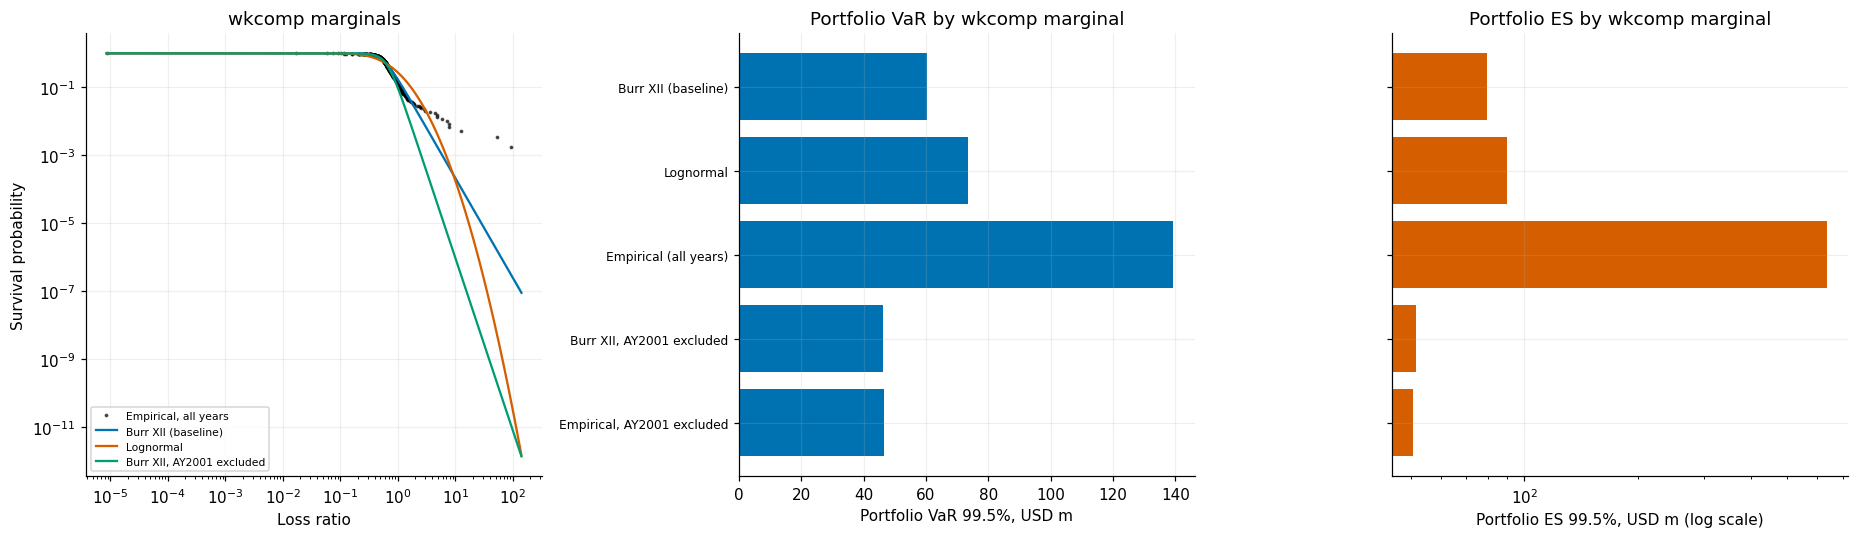

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x_grid = np.geomspace(lr_wk.min(), lr_wk.max() * 1.5, 500)
lr_sorted = np.sort(lr_wk)
surv_emp = 1 - np.arange(1, len(lr_sorted) + 1) / (len(lr_sorted) + 1)
axes[0].plot(lr_sorted, surv_emp, '.', ms=3, color='k', alpha=0.6, label='Empirical, all years')
for name, color in [('Burr XII (baseline)', 'C0'), ('Lognormal', 'C3'), ('Burr XII, AY2001 excluded', 'C2')]:
    axes[0].plot(x_grid, 1 - alternatives[name].cdf(x_grid), color=color, label=name)
axes[0].set_xscale('log'); axes[0].set_yscale('log'); axes[0].set_xlabel('Loss ratio'); axes[0].set_ylabel('Survival probability')
axes[0].set_title('wkcomp marginals'); axes[0].legend(fontsize=7)

names = list(robust.index)
ypos = np.arange(len(names))
axes[1].barh(ypos, robust['portfolio VaR99.5'], color='C0')
axes[1].set_yticks(ypos); axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_xlabel('Portfolio VaR 99.5%, USD m'); axes[1].set_title('Portfolio VaR by wkcomp marginal'); axes[1].invert_yaxis()
axes[2].barh(ypos, robust['portfolio ES99.5'], color='C3')
axes[2].set_xscale('log'); axes[2].set_yticks(ypos); axes[2].set_yticklabels([])
axes[2].set_xlabel('Portfolio ES 99.5%, USD m (log scale)'); axes[2].set_title('Portfolio ES by wkcomp marginal'); axes[2].invert_yaxis()
plt.tight_layout(); plt.show()

**Reading the table.**

- Changing only the wkcomp marginal moves the independence portfolio VaR 99.5% from USD 46m (AY2001 excluded) to 60m (baseline Burr), 73m (lognormal) and 139m (empirical, all years). That is a factor of three between the lowest and the highest. ES moves much more, from USD 51m to 638m.
- The empirical all-years figure rests on two observations (loss ratios of 52 and 94, both AY2001). Its bootstrap band for the stand-alone VaR 99.5% is USD 57m to 641m, against 30m to 52m for a refitted Burr.
- Once AY2001 is removed the Burr fit and the empirical distribution agree in the tail (stand-alone VaR USD 21.0m and 21.8m). Most of the disagreement is about that year's premium data, not about the choice of family.
- Diversification moves too: D_VaR runs from 21% (empirical, all years) to 41% (AY2001 excluded), D_K from 26% to 63%.

**Consequence.** The baseline is not shown to be conservative or optimistic; it sits inside a wide band set by a data-quality decision. Notebook 06 puts this band next to the spread produced by different dependence assumptions.

In [14]:
marginal_robustness = {
    'unit': 'USD millions', 'dependence': 'independence', 'n_sim': N_SIM,
    'alternatives': robust.reset_index().to_dict('records'),
    'wkcomp_loss_ratio_quantiles': q_table.to_dict('index'),
    'ay2001': {'n_companies': int((wk_pos.AccidentYear == 2001).sum()),
               'n_of_top12': n_top_2001,
               'largest_other_year_LR': float(wk_pos.loc[wk_pos.AccidentYear != 2001, 'LossRatio'].max())},
    'gpd_tail_not_used': {k: (float(v) if isinstance(v, float) else v) for k, v in pot.info.items()},
    'bootstrap_var995_usd_m': boot_table.to_dict('index'), 'bootstrap_resamples': B,
}
with open(result_path('marginal_robustness.json'), 'w') as f:
    json.dump(marginal_robustness, f, indent=2, default=float)
print('Saved results/portfolio/marginal_robustness.json')

Saved results/portfolio/marginal_robustness.json


In [15]:
result = MultiLineResults(
    lines=LINES,
    fits={l: fits[l].__dict__ for l in LINES},
    unit='USD thousands',
    standalone_mean={l: float(standalone_mean[l]) for l in LINES},
    standalone_var995={l: float(standalone_v995[l]) for l in LINES},
    standalone_es995={l: float(standalone_es[l]) for l in LINES},
    sum_standalone_var995=float(sum_sa),
    portfolio_mean=float(port_mean),
    portfolio_var995=float(port_v995),
    portfolio_es995=float(port_es),
    d_var=float(d_var),
    d_k=float(d_k),
    n_sim=N_SIM, seed=1000,
)
result.to_json(result_path('multi_line_results.json'))
print("Saved results/portfolio/multi_line_results.json -- notebook 06 loads it rather than hard-coding the numbers (unit: USD thousands).")


Saved results/portfolio/multi_line_results.json -- notebook 06 loads it rather than hard-coding the numbers (unit: USD thousands).


## Notes

- Marginals are positive company-year loss ratios at lag 10, scaled to USD millions by the six median premiums.
- Independence is an assumption here; notebook 06 tries others.
- D_VaR (37.3%) and D_K (52.8%) are different measures and are always labelled.
- wkcomp marginal risk is large: portfolio VaR 99.5% runs from USD 46m to 139m across the alternatives, driven by AY2001.
- None of this is a single insurer's capital requirement.

In [16]:
record_results('multi_line_results.json', 'marginal_robustness.json')